## Notebook 4 - XGBoost Demand Forecasting

In [1]:
# 1. INSTALL & IMPORTS

!pip install xgboost optuna --quiet

import pandas as pd
import numpy as np
import xgboost as xgb
import optuna
import joblib

# FIX: Silence Optuna trial logs — as they flood the output
optuna.logging.set_verbosity(optuna.logging.WARNING)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.0 MB/s eta 0:00:00


In [2]:
# 2. LOAD DATA

df = pd.read_csv("rossmann_features.csv", parse_dates=['Date'])

with open("feature_cols.txt") as f:
    FEATURE_COLS = [line.strip() for line in f.readlines()]

print("Data shape:", df.shape)


Data shape: (844338, 35)


In [3]:
# 3. TARGET TRANSFORM (log1p)
# log1p compresses the skewed sales distribution.
# We invert with expm1 when evaluating RMSPE.

df['log_sales'] = np.log1p(df['Sales'])


In [4]:
# 4. TIME SPLIT
# Train on everything before June 1 2015 — validation on last 2 months

cutoff_date = "2015-06-01"
train_df = df[df['Date'] < cutoff_date].copy()
valid_df = df[df['Date'] >= cutoff_date].copy()

print("Train:", train_df.shape)
print("Valid:", valid_df.shape)

train_dates = train_df['Date'].values


Train: (785727, 36)
Valid: (58611, 36)


In [5]:
# 5. PREPARE FEATURES & TARGET

X_train = train_df[FEATURE_COLS]
y_train = train_df['log_sales']
X_valid = valid_df[FEATURE_COLS]
y_valid = valid_df['log_sales']


In [6]:
# 6. RMSPE METRIC
# Root Mean Square Percentage Error — penalises proportional errors

def rmspe(y_true, y_pred):
    y_true = np.expm1(y_true)
    y_pred = np.expm1(y_pred)
    mask   = y_true > 0
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    return np.sqrt(np.mean(((y_true - y_pred) / y_true) ** 2))


In [7]:
# 7. BASELINE MODEL

baseline_model = xgb.XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=8,
    subsample=0.8, colsample_bytree=0.8, random_state=42, tree_method='hist'
)
baseline_model.fit(X_train, y_train)
baseline_preds = baseline_model.predict(X_valid)
print("Baseline RMSPE:", rmspe(y_valid, baseline_preds))


Baseline RMSPE: 0.01161562151731105


In [9]:
# 8. WALK-FORWARD TUNING (20 trials, early stopping)
# Limited trials due to runtime; can increase to 30+ in production

def objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators',     300, 700),
        'learning_rate':    trial.suggest_float('learning_rate',  0.02, 0.1),
        'max_depth':        trial.suggest_int('max_depth',        5,   9),
        'subsample':        trial.suggest_float('subsample',      0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'random_state':     42,
        'tree_method':      'hist',
        'early_stopping_rounds': 20
    }

    unique_dates  = np.sort(pd.Series(train_dates).unique())
    split_idx     = int(0.8 * len(unique_dates))
    train_cut     = unique_dates[split_idx]

    X_tune    = X_train[train_df['Date'] < train_cut]
    y_tune    = y_train[train_df['Date'] < train_cut]
    X_val_t   = X_train[train_df['Date'] >= train_cut]
    y_val_t   = y_train[train_df['Date'] >= train_cut]

    model = xgb.XGBRegressor(**params)
    model.fit(X_tune, y_tune, eval_set=[(X_val_t, y_val_t)], verbose=False)
    return rmspe(y_val_t, model.predict(X_val_t))

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)
print("Best Params:", study.best_params)


Best Params: {'n_estimators': 647, 'learning_rate': 0.03340828760295036, 'max_depth': 7, 'subsample': 0.8849895450004004, 'colsample_bytree': 0.9599443734796672}


In [10]:
# 9. FINAL MODEL

best_params = {k: v for k, v in study.best_params.items()
               if k != 'early_stopping_rounds'}

best_model = xgb.XGBRegressor(**best_params)
best_model.fit(X_train, y_train)

final_preds = best_model.predict(X_valid)
print("Final RMSPE (unseen test):", rmspe(y_valid, final_preds))


Final RMSPE (unseen test): 0.01090081410858458


In [11]:
# STORE TYPE PERFORMANCE


valid_df['pred'] = np.expm1(final_preds)

storetype_perf = valid_df.groupby('StoreType').apply(
    lambda x: np.sqrt(np.mean(((x['Sales'] - x['pred']) / x['Sales'])**2)),include_groups=False
)

print("\nRMSPE by StoreType:")
print(storetype_perf)


RMSPE by StoreType:
StoreType
0    0.013113
1    0.016645
2    0.006366
3    0.007149
dtype: float64


          feature  importance
22         avg_4w    0.522442
26         dev_4w    0.264786
24      median_4w    0.109323
2           Promo    0.061413
21        lag_365    0.008430
1       DayOfWeek    0.007727
8       StoreType    0.006296
3   SchoolHoliday    0.002558
23         std_4w    0.002416
25         avg_1w    0.002323


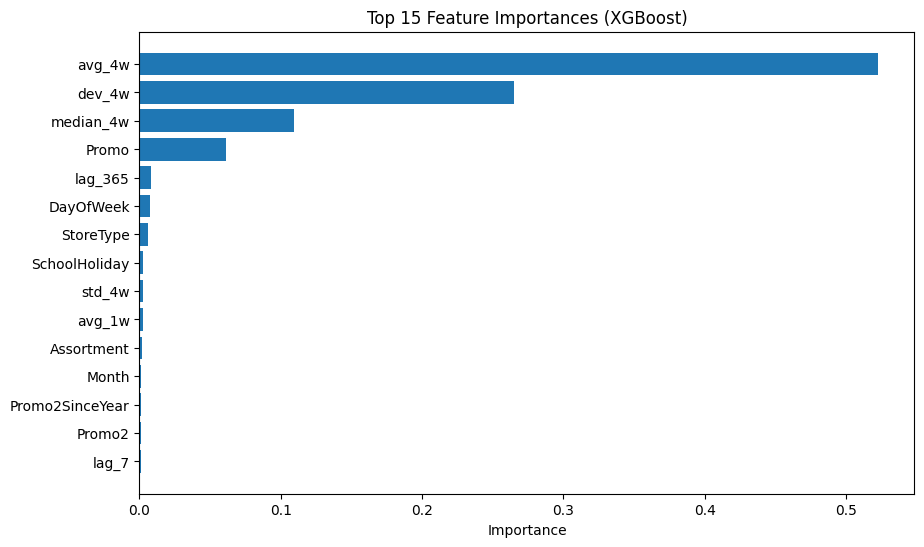

In [12]:
# FEATURE IMPORTANCE
# Feature importance shows rolling averages dominate demand prediction

import matplotlib.pyplot as plt

importance = pd.DataFrame({
    'feature': FEATURE_COLS,
    'importance': best_model.feature_importances_
}).sort_values(by='importance', ascending=False)

print(importance.head(10))

# Plot
plt.figure(figsize=(10,6))
plt.barh(importance['feature'][:15][::-1], importance['importance'][:15][::-1])
plt.title("Top 15 Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.show()

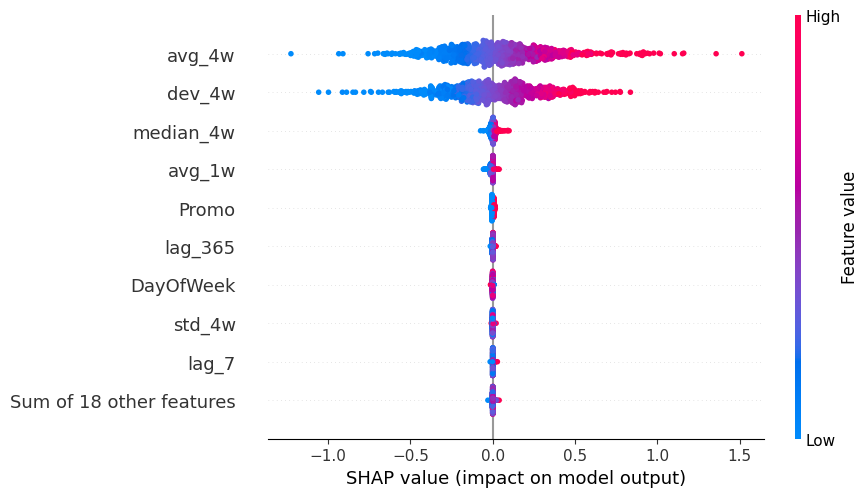

In [13]:
#SHAP explainability
!pip install shap --quiet

import shap

explainer = shap.TreeExplainer(best_model)
shap_values = explainer(X_valid.sample(1000))

shap.plots.beeswarm(shap_values)

In [14]:
# 10. SAVE PREDICTIONS & MODEL

valid_df['xgb_pred'] = np.expm1(final_preds)
valid_df[['Store','Date','Sales','xgb_pred']].to_csv("xgb_predictions.csv", index=False)

joblib.dump(best_model, "xgboost_model.pkl")
print("Saved: xgb_predictions.csv")
print("Saved: xgboost_model.pkl")


Saved: xgb_predictions.csv
Saved: xgboost_model.pkl
